In [29]:
# 📦 Cell 1: Imports and Initial Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")


In [30]:

# 📦 Cell 2: Load and Preprocess the Data
music_data = pd.read_csv("spotify_data.csv")
music_data.dropna(inplace=True)
music_data = music_data[music_data['popularity'] >= 40]
music_data.drop(columns=['Unnamed: 0', 'track_id'], inplace=True)


In [31]:

# 📦 Cell 3: Encode Categorical Columns
columns_to_encode = ['artist_name', 'track_name', 'genre', 'year']
label_encoder = LabelEncoder()
for column in columns_to_encode:
    music_data[column].fillna('unknown', inplace=True)
    music_data[column + '_encoded'] = label_encoder.fit_transform(music_data[column])


In [32]:

# 📦 Cell 4: Normalize Numerical Data
def normalize_column(col):
    max_d = music_data[col].max()
    min_d = music_data[col].min()
    music_data[col] = (music_data[col] - min_d) / (max_d - min_d)

num_types = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
num = music_data.select_dtypes(include=num_types)
for col in num.columns:
    if col != 'year':
        normalize_column(col)


In [33]:

# 📦 Cell 5: KMeans Clustering and Cluster Labeling
from sklearn.cluster import KMeans
km = KMeans(n_clusters=10)
cat = km.fit_predict(num)
music_data['cat'] = cat
normalize_column('cat')

cluster_pipeline = Pipeline([('scaler', StandardScaler()), ('kmeans', KMeans(n_clusters=10))])
X_full = music_data.select_dtypes(np.number)
music_data['cluster'] = cluster_pipeline.fit_predict(X_full)


In [34]:

# 📦 Cell 6: PCA Dimensionality Reduction
X = music_data.select_dtypes(np.number).drop(columns=['cat', 'cluster', 'year'])
y = music_data['cluster']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print(f"Original features: {X.shape[1]}, After PCA: {X_pca.shape[1]}")


Original features: 18, After PCA: 16


In [35]:

# 📦 Cell 7: Train/Test Split
X_train_pca, X_rem_pca, y_train, y_rem = train_test_split(X_pca, y, train_size=0.8, random_state=0)
X_valid_pca, X_test_pca, y_valid, y_test = train_test_split(X_rem_pca, y_rem, test_size=0.5)


In [36]:

# 📦 Cell 8: Train KNN Classifiers
knn1_pca = KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=1)
knn5_pca = KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=4)
knn10_pca = KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=20)

knn1_pca.fit(X_train_pca, y_train)
knn5_pca.fit(X_train_pca, y_train)
knn10_pca.fit(X_train_pca, y_train)


KNeighborsClassifier(algorithm='brute', metric='cosine', n_neighbors=20)

In [37]:

# 📦 Cell 9: Predictions
y_pred_1_pca = knn1_pca.predict(X_valid_pca)
y_pred_5_pca = knn5_pca.predict(X_valid_pca)
y_pred_10_pca = knn10_pca.predict(X_valid_pca)


In [38]:

# 📦 Cell 10: Evaluation
print("\n✅ Accuracy after PCA:")
print("k=1:", accuracy_score(y_valid, y_pred_1_pca) * 100)
print("k=4:", accuracy_score(y_valid, y_pred_5_pca) * 100)
print("k=20:", accuracy_score(y_valid, y_pred_10_pca) * 100)

print("\n📊 Classification Report (k=4):\n", classification_report(y_valid, y_pred_5_pca))



✅ Accuracy after PCA:
k=1: 79.96701154595891
k=4: 83.32583595741491
k=20: 86.84960263907632

📊 Classification Report (k=4):
               precision    recall  f1-score   support

           0       0.69      0.80      0.74      2100
           1       0.86      0.83      0.84      1797
           2       0.82      0.91      0.86       972
           3       0.83      0.88      0.86       682
           4       0.89      0.90      0.89       567
           5       0.84      0.76      0.80      2185
           6       0.83      0.97      0.90       703
           7       0.89      0.85      0.87      2010
           8       0.90      0.81      0.85      1457
           9       0.91      0.83      0.87       865

    accuracy                           0.83     13338
   macro avg       0.85      0.85      0.85     13338
weighted avg       0.84      0.83      0.83     13338



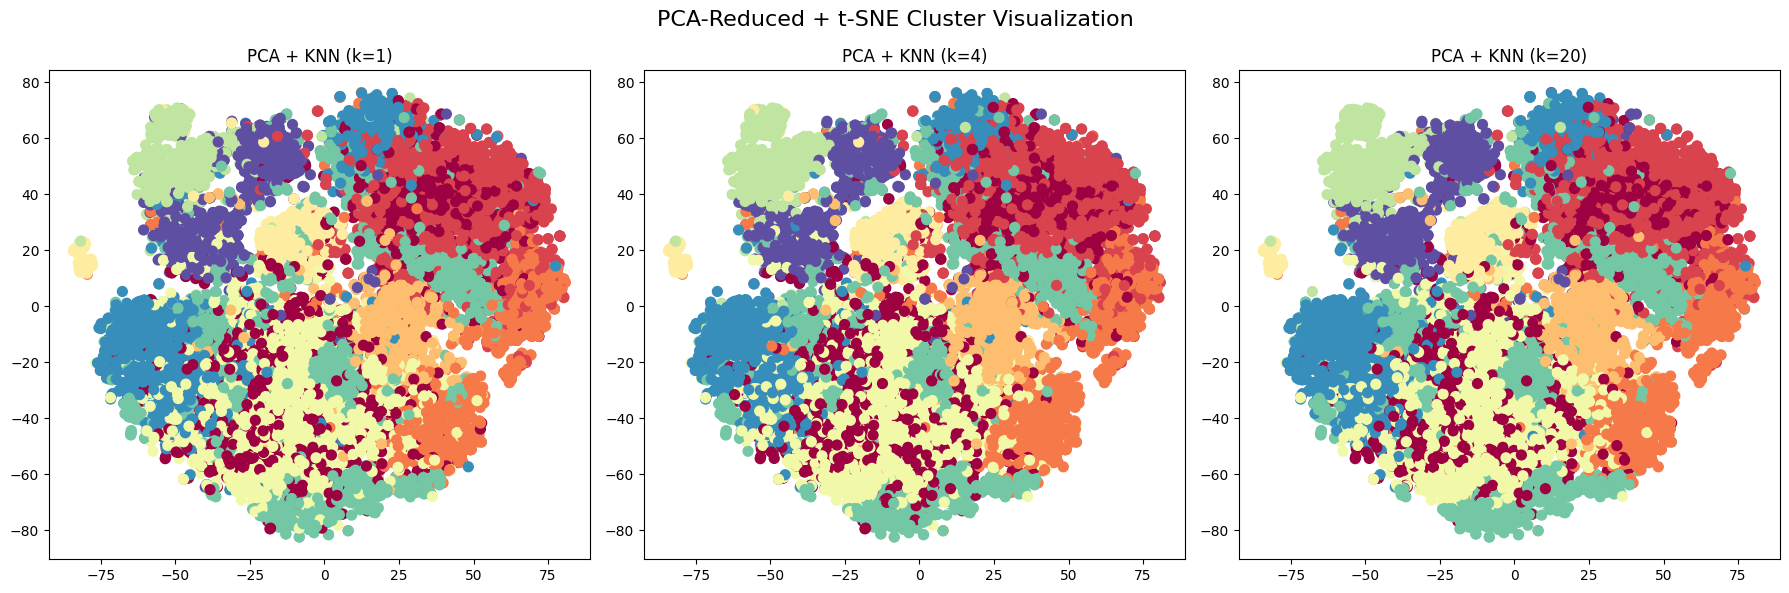

In [39]:

# 📦 Cell 11: t-SNE Visualization
cmap = sb.cubehelix_palette(as_cmap=True)
tsne_pca = TSNE(n_components=2, random_state=0)
tsne_data_pca = tsne_pca.fit_transform(X_test_pca)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(tsne_data_pca[:, 0], tsne_data_pca[:, 1], c=knn1_pca.predict(X_test_pca), cmap='Spectral', s=50)
plt.title("PCA + KNN (k=1)")

plt.subplot(1, 3, 2)
plt.scatter(tsne_data_pca[:, 0], tsne_data_pca[:, 1], c=knn5_pca.predict(X_test_pca), cmap='Spectral', s=50)
plt.title("PCA + KNN (k=4)")

plt.subplot(1, 3, 3)
plt.scatter(tsne_data_pca[:, 0], tsne_data_pca[:, 1], c=knn10_pca.predict(X_test_pca), cmap='Spectral', s=50)
plt.title("PCA + KNN (k=20)")

plt.suptitle("PCA-Reduced + t-SNE Cluster Visualization", fontsize=16)
plt.tight_layout()
plt.show()

In [40]:
music_data = pd.read_csv("spotify_data.csv")
music_data.head()


,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [41]:
music_data.shape

(1159764, 20)

In [42]:
music_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  object 
 2   track_name        1159763 non-null  object 
 3   track_id          1159764 non-null  object 
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  object 
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          1159764 non-null  float64
 16  

In [43]:
music_data.isnull().sum()

Unnamed: 0           0
artist_name         15
track_name           1
track_id             0
popularity           0
year                 0
genre                0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
dtype: int64

In [44]:
music_data.dropna(inplace=True)

In [45]:
music_data.isnull().sum()

Unnamed: 0          0
artist_name         0
track_name          0
track_id            0
popularity          0
year                0
genre               0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

In [46]:
import pandas as pd

# Assuming 'data' is your DataFrame
music_data = music_data[music_data['popularity'] >= 40]


In [47]:
music_data.shape

(133376, 20)

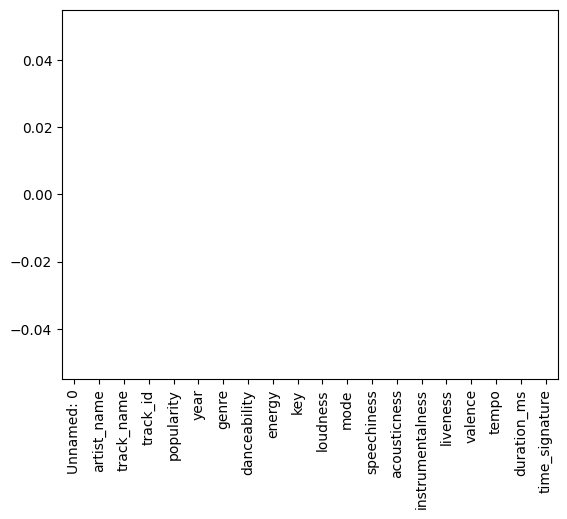

In [48]:
music_data.isnull().sum().plot.bar()
plt.show()

In [49]:
music_data.select_dtypes(np.number)

,Unnamed: 0,popularity,year,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,68,2012,0.483,0.303,4,-10.058,1,0.0429,0.694000,0.000000,0.1150,0.139,133.406,240166,3
1,1,50,2012,0.572,0.454,3,-10.286,1,0.0258,0.477000,0.000014,0.0974,0.515,140.182,216387,4
2,2,57,2012,0.409,0.234,3,-13.711,1,0.0323,0.338000,0.000050,0.0895,0.145,139.832,158960,4
3,3,58,2012,0.392,0.251,10,-9.845,1,0.0363,0.807000,0.000000,0.0797,0.508,204.961,304293,4
4,4,54,2012,0.430,0.791,6,-5.419,0,0.0302,0.072600,0.019300,0.1100,0.217,171.864,244320,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159047,1471681,50,2011,0.640,0.792,10,-4.875,0,0.0419,0.000538,0.604000,0.0745,0.383,128.001,368000,4
1159048,1471690,45,2011,0.527,0.866,10,-6.838,0,0.0346,0.000174,0.615000,0.1600,0.266,128.033,182930,4
1159049,1471696,47,2011,0.541,0.931,10,-9.687,0,0.0552,0.326000,0.129000,0.3250,0.148,128.584,189701,4
1159050,1471704,45,2011,0.459,0.350,7,-15.912,0,0.0356,0.040700,0.810000,0.1370,0.037,89.890,345171,3


In [50]:
music_data.shape

(133376, 20)

In [51]:
music_data.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [52]:
music_data.drop(columns=['Unnamed: 0'], inplace=True)

In [53]:
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [54]:

# 📊 Heatmap of correlations
plt.figure(figsize=(12, 8))
sb.heatmap(visual_data.corr(), annot=True, square=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


NameError: name 'visual_data' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:

# 📈 Feature trends per year using bar plots
plt.figure(figsize=(20, 20))
for i in tqdm(np.arange(1, len(visual_data.columns))):
    plt.subplot(9, 2, i)
    sb.barplot(x=music_data['year'], y=visual_data[visual_data.columns[i]])
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

# 📦 Boxplots of all numerical features (excluding year)
music_data.select_dtypes(np.number).drop(columns=['year']).plot(kind='box', figsize=(20, 20), fontsize=10)
plt.title("Boxplot of Numerical Features")
plt.show()


In [ ]:

# 🎯 Correlation matrix with background gradient
corr_matrix = visual_data.corr()
corr_matrix.style.background_gradient(cmap='coolwarm')


In [ ]:
music_data.drop(columns=['track_id'], inplace=True)

In [ ]:
visual_data = music_data.drop(columns=['track_name', 'artist_name', 'year', 'genre'])

plt.figure(figsize=(20, 20))
for i in tqdm(np.arange(1, len(visual_data.columns))):
    plt.subplot(9, 2, i)
    sb.barplot(x=music_data.year,y=visual_data[visual_data.columns[i]])
    plt.xticks(rotation=45);
plt.show()

In [ ]:
corr_matrix = visual_data.corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

In [ ]:
plt.subplots(figsize=(12, 8))
sb.heatmap(visual_data.corr(), annot=True, square=True)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'music_data' is your DataFrame containing the music dataset
columns_to_encode = ['artist_name', 'track_name', 'genre', 'year']

# Create a label encoder object
label_encoder = LabelEncoder()

# Encode each column
for column in columns_to_encode:
    # Fill missing values with a placeholder before encoding
    music_data[column].fillna('unknown', inplace=True)
    # Fit label encoder and transform the column
    music_data[column + '_encoded'] = label_encoder.fit_transform(music_data[column])

# Display the first few rows of the encoded DataFrame
print(music_data.head())


In [ ]:
import os
import seaborn as sns
import plotly.express as px 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import euclidean_distances
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings("ignore")

In [ ]:
def normalize_column(col):
    max_d = music_data[col].max()
    min_d = music_data[col].min()
    music_data[col] = (music_data[col] - min_d)/(max_d - min_d)

In [ ]:
num_types = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
num = music_data.select_dtypes(include=num_types)
        
for col in num.columns:
    if col != 'year':
        normalize_column(col) 

In [ ]:
music_data.select_dtypes(np.number).drop(columns = ['year']).plot(kind='box' ,figsize=(20, 20) ,fontsize=10)

In [ ]:
encoded_genres_df = pd.DataFrame(music_data, columns=columns_to_encode)

# Concatenate the encoded genres DataFrame with the original dataset
music_data = pd.concat([music_data, encoded_genres_df], axis=1)

# View the dataset with the encoded genres
music_data.head()

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=10)
cat = km.fit_predict(num)
music_data['cat'] = cat
normalize_column('cat')

In [ ]:
music_data.cat[:10]

In [ ]:
cluster_pipeline = Pipeline([('scaler', StandardScaler()), ('kmeans', KMeans(n_clusters=10))])
X = music_data.select_dtypes(np.number)
cluster_pipeline.fit(X)
music_data['cluster'] = cluster_pipeline.predict(X)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X = music_data.select_dtypes(np.number).drop(columns = ['cat','cluster','year']).copy()
y = music_data['cluster']


In [ ]:
X_train, X_rem, y_train, y_rem = train_test_split(X,y, train_size=0.8, random_state=0)

X_valid, X_test, y_valid, y_test = train_test_split(X_rem,y_rem, test_size=0.5)

print(X_train.shape), print(y_train.shape)
print(X_valid.shape), print(y_valid.shape)
print(X_test.shape), print(y_test.shape)

In [ ]:
knn1= KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=1)
knn5= KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=4)
knn10= KNeighborsClassifier(metric='cosine', algorithm='brute', n_neighbors=20)

In [ ]:
knn5.fit(X_train, y_train)
knn1.fit(X_train, y_train)
knn10.fit(X_train, y_train)

knn5.fit(X_valid, y_valid)
knn1.fit(X_valid, y_valid)
knn10.fit(X_valid, y_valid)

knn5.fit(X_train, y_train)
knn1.fit(X_train, y_train)
knn10.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_valid)
y_pred_1 = knn1.predict(X_valid)
y_pred_10 = knn10.predict(X_valid)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy with k=5", accuracy_score(y_valid, y_pred_5)*100)
print("Accuracy with k=8", accuracy_score(y_valid, y_pred_1)*100)
print("Accuracy with k=11", accuracy_score(y_valid, y_pred_10)*100)  

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_valid, y_pred_1))
print(confusion_matrix(y_valid, y_pred_5))
print(confusion_matrix(y_valid, y_pred_10))

In [ ]:
print(classification_report(y_valid, y_pred_1))
print(classification_report(y_valid, y_pred_5))
print(classification_report(y_valid, y_pred_10))

In [ ]:
tsne_model = TSNE(n_components = 2, random_state = 0)
tsne_data_X_valid = tsne_model.fit_transform(X_test)

In [ ]:

cmap = sb.cubehelix_palette(as_cmap=True)
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
plt.scatter(tsne_data_X_valid[:,0], tsne_data_X_valid[:,1], c=y_pred_5, marker= '*', s=100, cmap=cmap)
plt.title("Predicted values with k=4", fontsize=20)
plt.subplot(1,2,2)
plt.scatter(tsne_data_X_valid[:,0], tsne_data_X_valid[:,1], c=y_pred_1, marker= '*', s=100, cmap=cmap)
plt.title("Predicted values with k=1", fontsize=20)
plt.show()
plt.subplot(1,2,2)
plt.scatter(tsne_data_X_valid[:,0], tsne_data_X_valid[:,1], c=y_pred_10, marker= '*', s=100, cmap=cmap)
plt.title("Predicted values with k=20", fontsize=20)
plt.show()
